In [1]:
import pandas as pd
from CCA_utils import *

In [5]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('cca_panel_newdebt.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()


ovx_df = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')
ovx_df['date'] = pd.to_datetime(ovx_df['date'])

oil_prices = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_prices['Date'] = pd.to_datetime(oil_prices['Date'])

cca_panel_df = cca_panel_df.merge(ovx_df[['date','OVXCLS']], on='date', how='left')
cca_panel_df = cca_panel_df.merge(oil_prices[['Date','Brent']], left_on='date', right_on='Date', how='left')


cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 52
freq = 'W'
k=1.64
n_paths=1
seed = 42
ovxqtl = 0.85



#This replace with msci corr with oil returns.
RHO_DEFAULT = 0.25

MSCI_EM_constituent_list = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "United Arab Emirates"]


THETA_MAP = {
    "Brazil":0.2, "Chile":0, "China":0, "Colombia":0.1, "Czechia":0, 
    "Egypt":0.2, "Greece":0, "Hungary":0, "India":0, "Indonesia":0,
    "South Korea":0.1, "Kuwait":0.1, "Malaysia":0.1, "Mexico":0.1, 
    "Peru":0, "Philippines":0, "Poland":0, "Qatar":0.5,
    "Saudi Arabia":0.5, "South Africa":0, "Taiwan":0, 
    "Thailand":0, "Turkey":0, "Dubai":0.5, "Abu Dhabi":0.5}


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_39132/1970167274.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_prices['Date'] = pd.to_datetime(oil_prices['Date'])


In [13]:
pricer = JumpDiffusionPricer(steps=52, n_paths=5000)

results = pd.DataFrame()
for country, group in cca_panel_df.groupby('country'):
    df = group.copy().sort_values('date').reset_index(drop=True)
    theta = 0.5
    eta = 0.1
    r_d = df['domestic_rate_in_units'] / 100
    r_f = df['risk_free_rate'] / 100
    M_bn = df['monetary_base_mn_localcurr'] / 1000
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd'] / 1000
    fx_rate = df['fx_rate']

    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

    df['P_oil_ref'] = df['Brent'].rolling(window=4, min_periods=4).mean()


    df['LCL_aug'] = df.apply(
    lambda row: augment_lcl(row['LCL_usd'], row['Brent'], row['P_oil_ref'],
                            theta, eta)[0]
    if not np.isnan(row['P_oil_ref']) and row['P_oil_ref'] > 0
    else row['LCL_usd'],
    axis=1)

    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_aug'] / df['LCL_aug'].shift(1))
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor
    
    # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                ext_D_bn, r_f
            )
        ]

    df['lamovx'] = np.where(
        df['OVXCLS'] < 30, 0, np.where(df['OVXCLS']<50,0.25,
        np.where(df['OVXCLS']<70, 0.5,1)))

        
    # --- Solve CCA for each week ---
    out = {'implied_V': [], 'implied_sigma_V': [], 'cca_converged': [],
           'distance_to_distress': [], 'default_prob': [],
           'model_spread_bps': [], 'put_value': [], 'risky_debt': [],
           'leverage': []}
    
    for i, row in df.iterrows():

        lam_i = row['lamovx']
        eta = 20

        cca_base = solve_CCA(row['LCL_usd'], row['sigma_lcl'], row['B_f'],
                                r_f.iloc[i], T)
        
        if lam_i==0:
            risk = compute_risk(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                            r_f.iloc[i], T)
        else:   
            risk = pricer.compute_risk_jd(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                                       r_f.iloc[i], T, lam=lam_i, eta=eta, seed=42)
                # store baseline results...
        out['implied_V'].append(cca_base['V'])
        out['implied_sigma_V'].append(cca_base['sigma_V'])
        out['cca_converged'].append(cca_base['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])
    print(f"  {country:5s} ")

  Abu Dhabi 
  Brazil 
  Chile 
  China 
  Colombia 
  Dubai 
  Egypt 
  Indonesia 
  Malaysia 
  Mexico 
  Philippines 
  Qatar 
  Saudi Arabia 
  South Africa 
  South Korea 
  Thailand 
  Turkey 


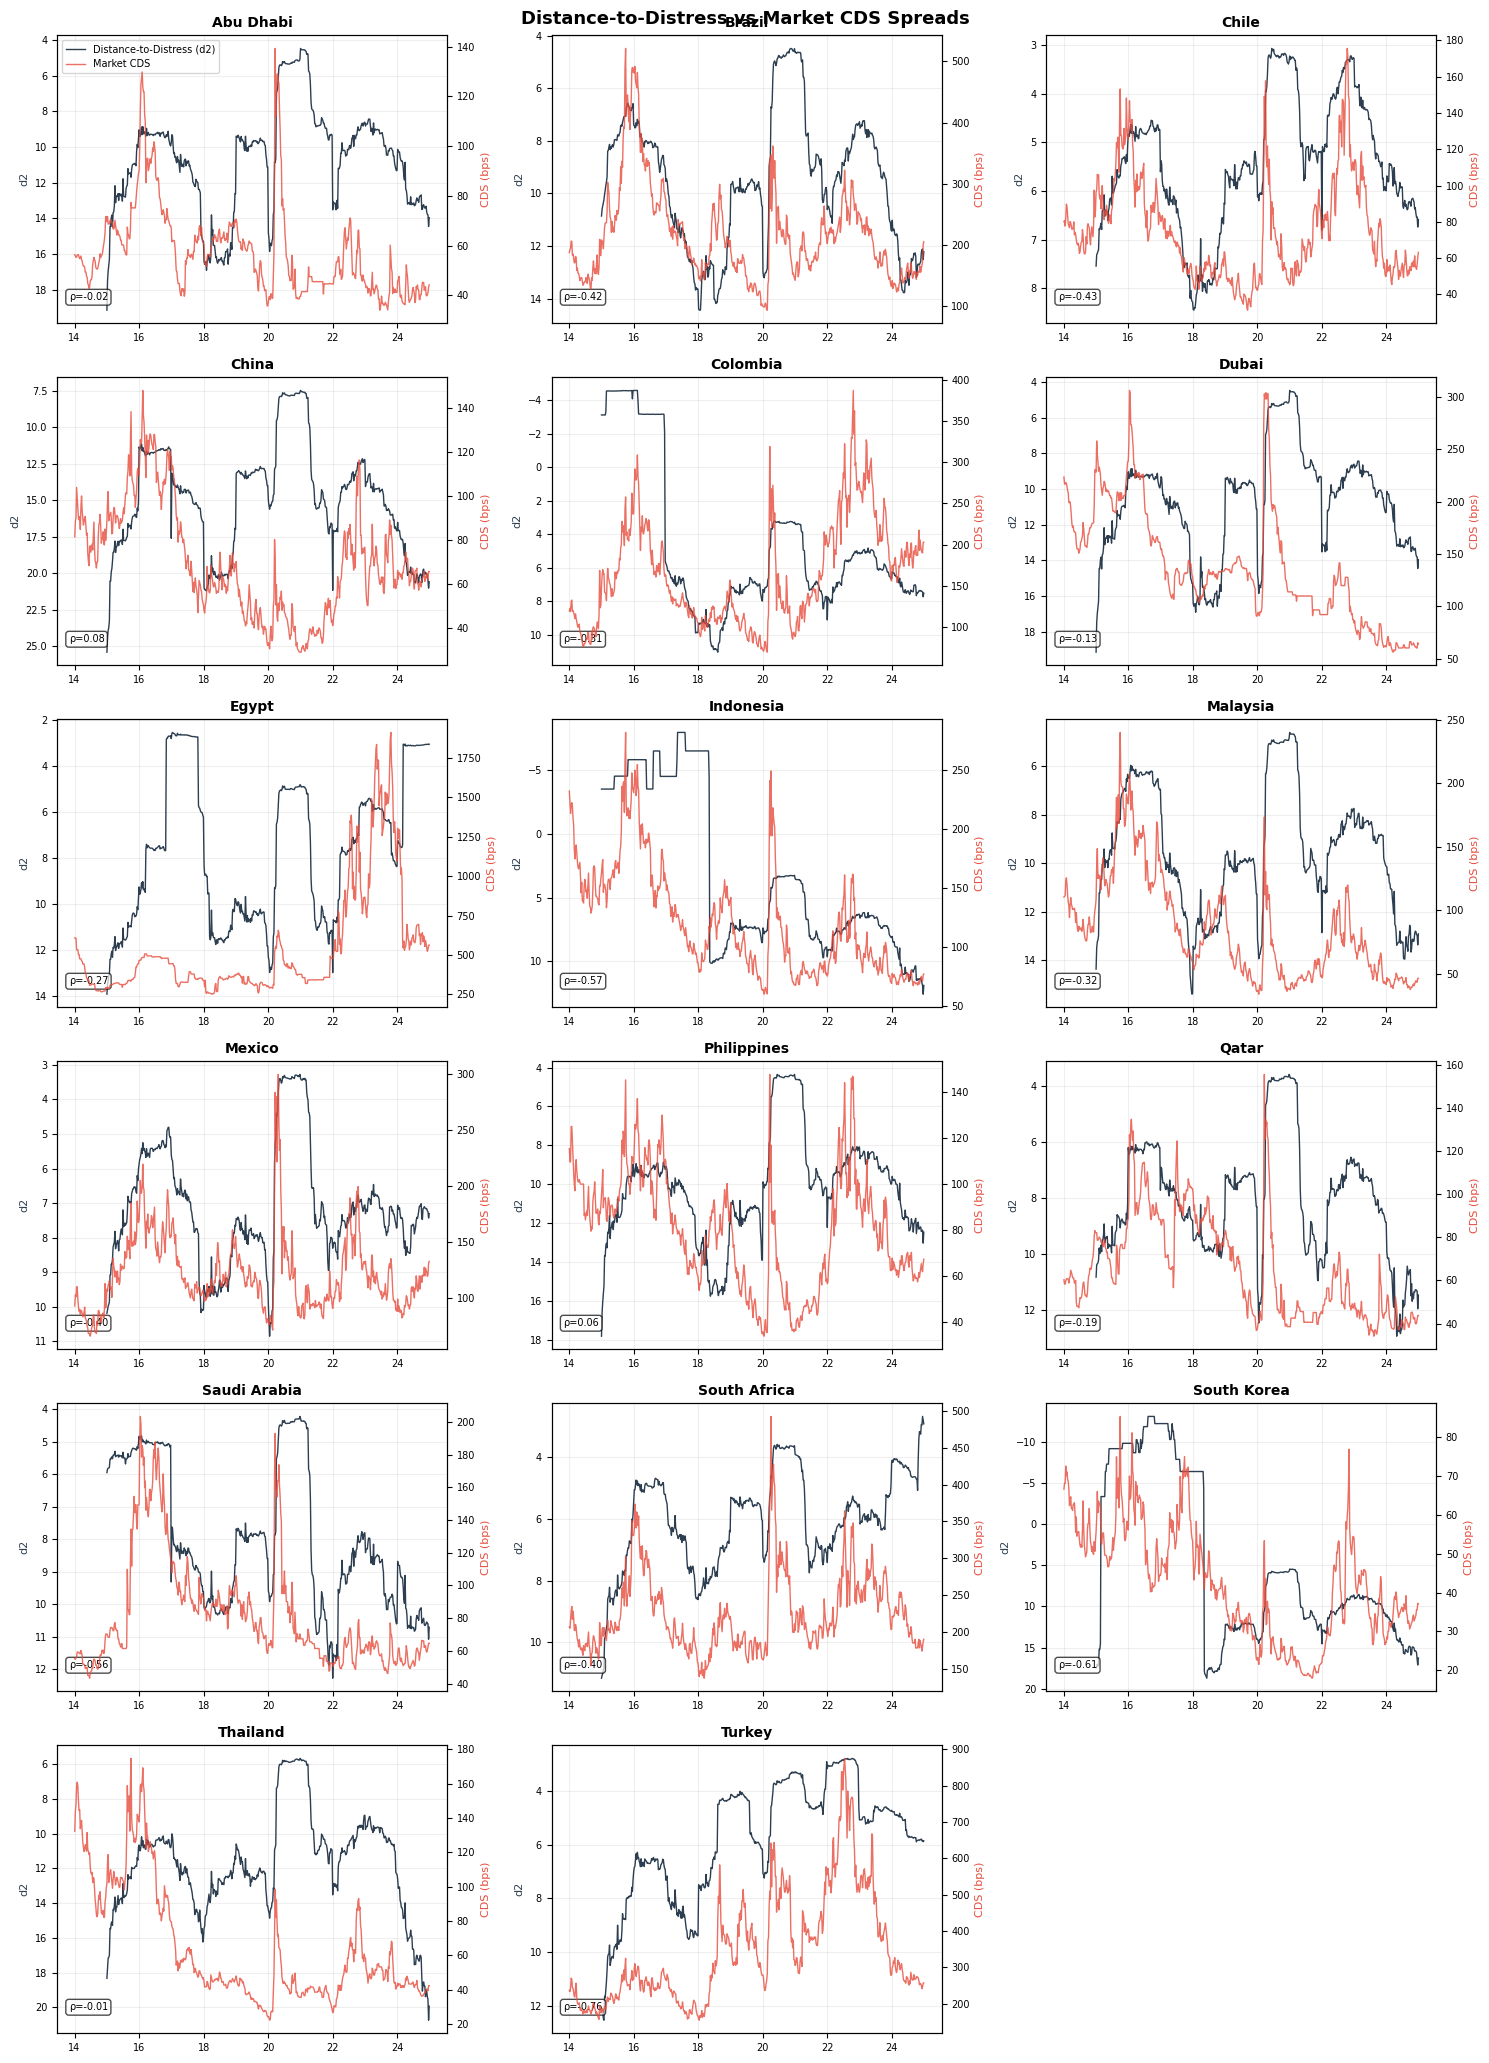

In [14]:
d2_vs_cds = plot_d2_vs_cds(results)

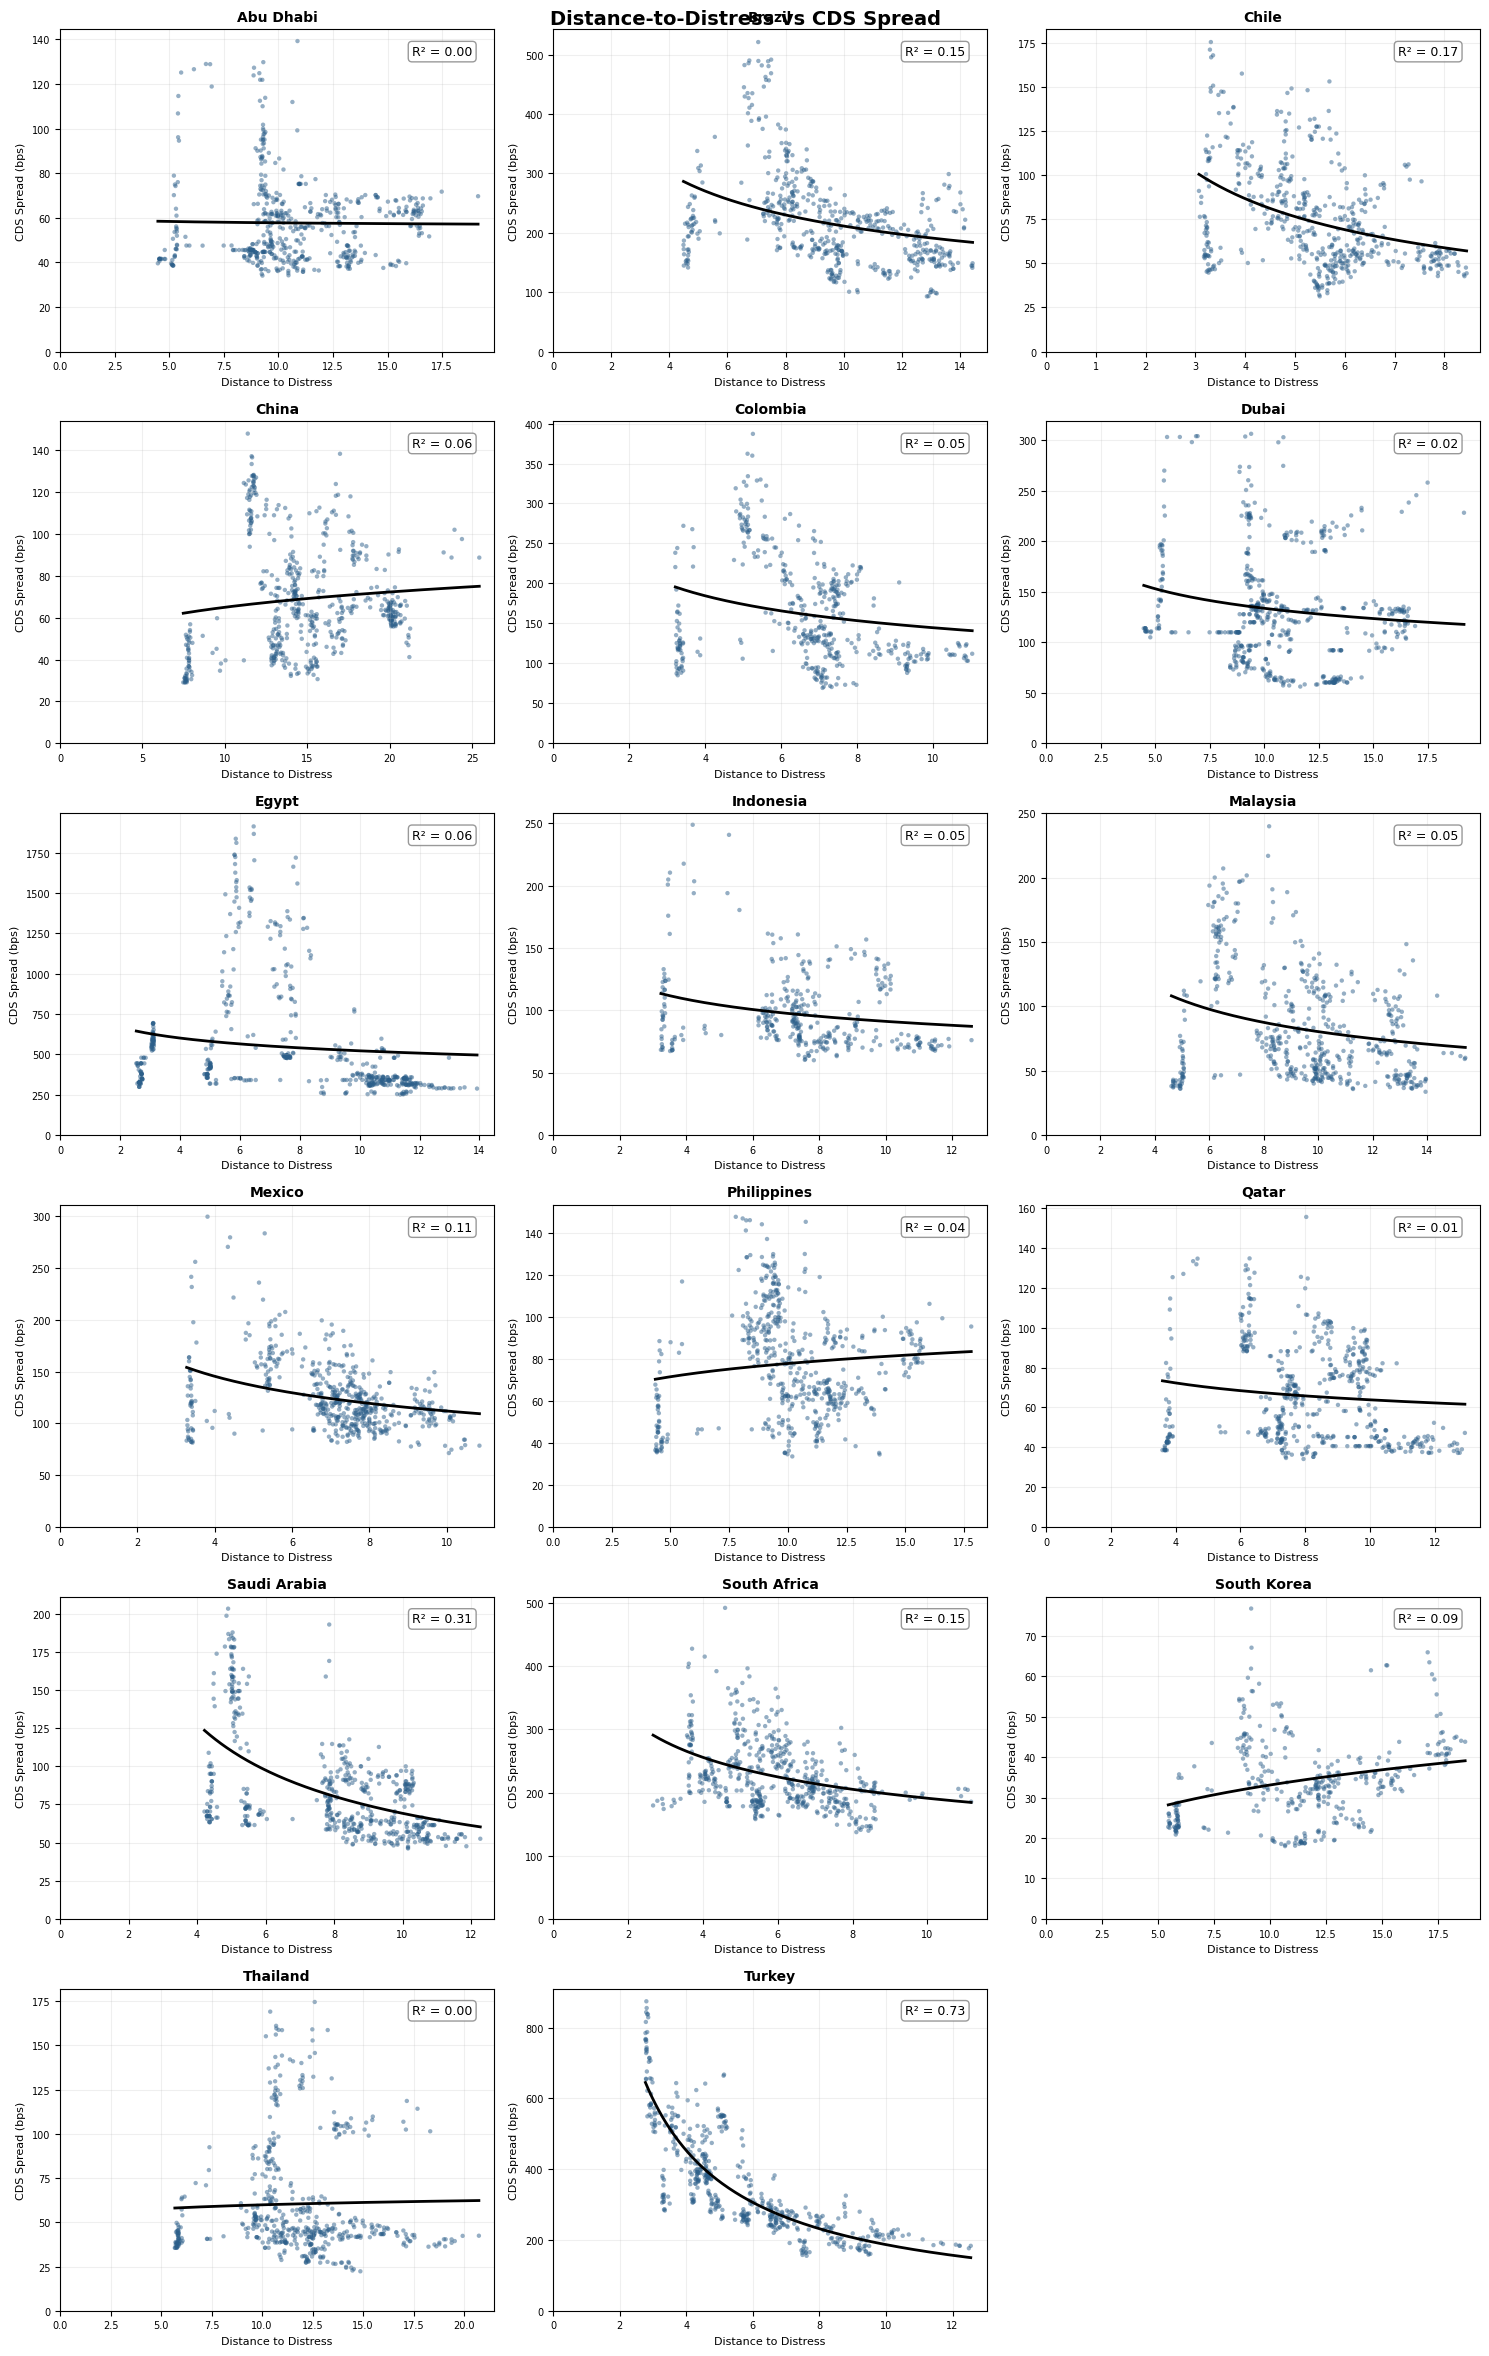

In [15]:
d2_scatter = plot_d2_scatter(results)